In [163]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [164]:
df = pd.read_csv("D:\Projects\Machine Learning\Telco Customer Churn Dataset using stremlit\Telco-Customer-Churn-Dataset-using-stremlit\data\Telco-Customer-Churn.csv")

In [165]:
df.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


### Performing the EDA

In [166]:
df.shape

(7043, 21)

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [168]:
# Converting the Total Charges as numberic.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [169]:
# After Converting or correcting the totalcharges datatype we got sum null values
print(df.isnull().sum())                 #null values = 11 in TotalCharges

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


### Handling null values in TotalCharges.

In [170]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\Briti Dipan\AppData\Local\Temp\ipykernel_28300\2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [171]:
#Removing Customer Id -- not needed
df.drop('customerID', axis=1, inplace=True)

### Checking unique values in each column in order to handle categorical values.


In [172]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"{col},  {df[col].unique()}")

gender,  ['Female' 'Male']
Partner,  ['Yes' 'No']
Dependents,  ['No' 'Yes']
PhoneService,  ['No' 'Yes']
MultipleLines,  ['No phone service' 'No' 'Yes']
InternetService,  ['DSL' 'Fiber optic' 'No']
OnlineSecurity,  ['No' 'Yes' 'No internet service']
OnlineBackup,  ['Yes' 'No' 'No internet service']
DeviceProtection,  ['No' 'Yes' 'No internet service']
TechSupport,  ['No' 'Yes' 'No internet service']
StreamingTV,  ['No' 'Yes' 'No internet service']
StreamingMovies,  ['No' 'Yes' 'No internet service']
Contract,  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling,  ['Yes' 'No']
PaymentMethod,  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn,  ['No' 'Yes']


In [173]:
df.replace("No internet service", "No", inplace=True)
df.replace("No phone service", "No", inplace=True)

In [174]:
for col in categorical_cols:
    print(f"{col},  {df[col].unique()}")

gender,  ['Female' 'Male']
Partner,  ['Yes' 'No']
Dependents,  ['No' 'Yes']
PhoneService,  ['No' 'Yes']
MultipleLines,  ['No' 'Yes']
InternetService,  ['DSL' 'Fiber optic' 'No']
OnlineSecurity,  ['No' 'Yes']
OnlineBackup,  ['Yes' 'No']
DeviceProtection,  ['No' 'Yes']
TechSupport,  ['No' 'Yes']
StreamingTV,  ['No' 'Yes']
StreamingMovies,  ['No' 'Yes']
Contract,  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling,  ['Yes' 'No']
PaymentMethod,  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn,  ['No' 'Yes']


### Handle categorical values i.e. dtype - objects


In [175]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

lcolumn = ["gender","Partner","Dependents","PhoneService","MultipleLines","OnlineSecurity",
           "OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","PaperlessBilling","Churn"]

for col in lcolumn:
    df[col] = le.fit_transform(df[col])

df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [176]:
df = pd.get_dummies(df, columns=["InternetService","Contract","PaymentMethod"], drop_first=True)

In [177]:
df.head(5).astype(int)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29,29,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56,1889,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53,108,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42,1840,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70,151,1,1,0,0,0,0,1,0


### Feature Scaling the dataset

### Visualiaztion

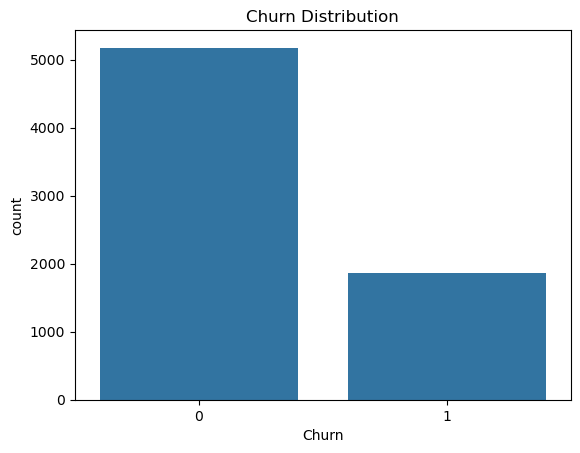

In [178]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

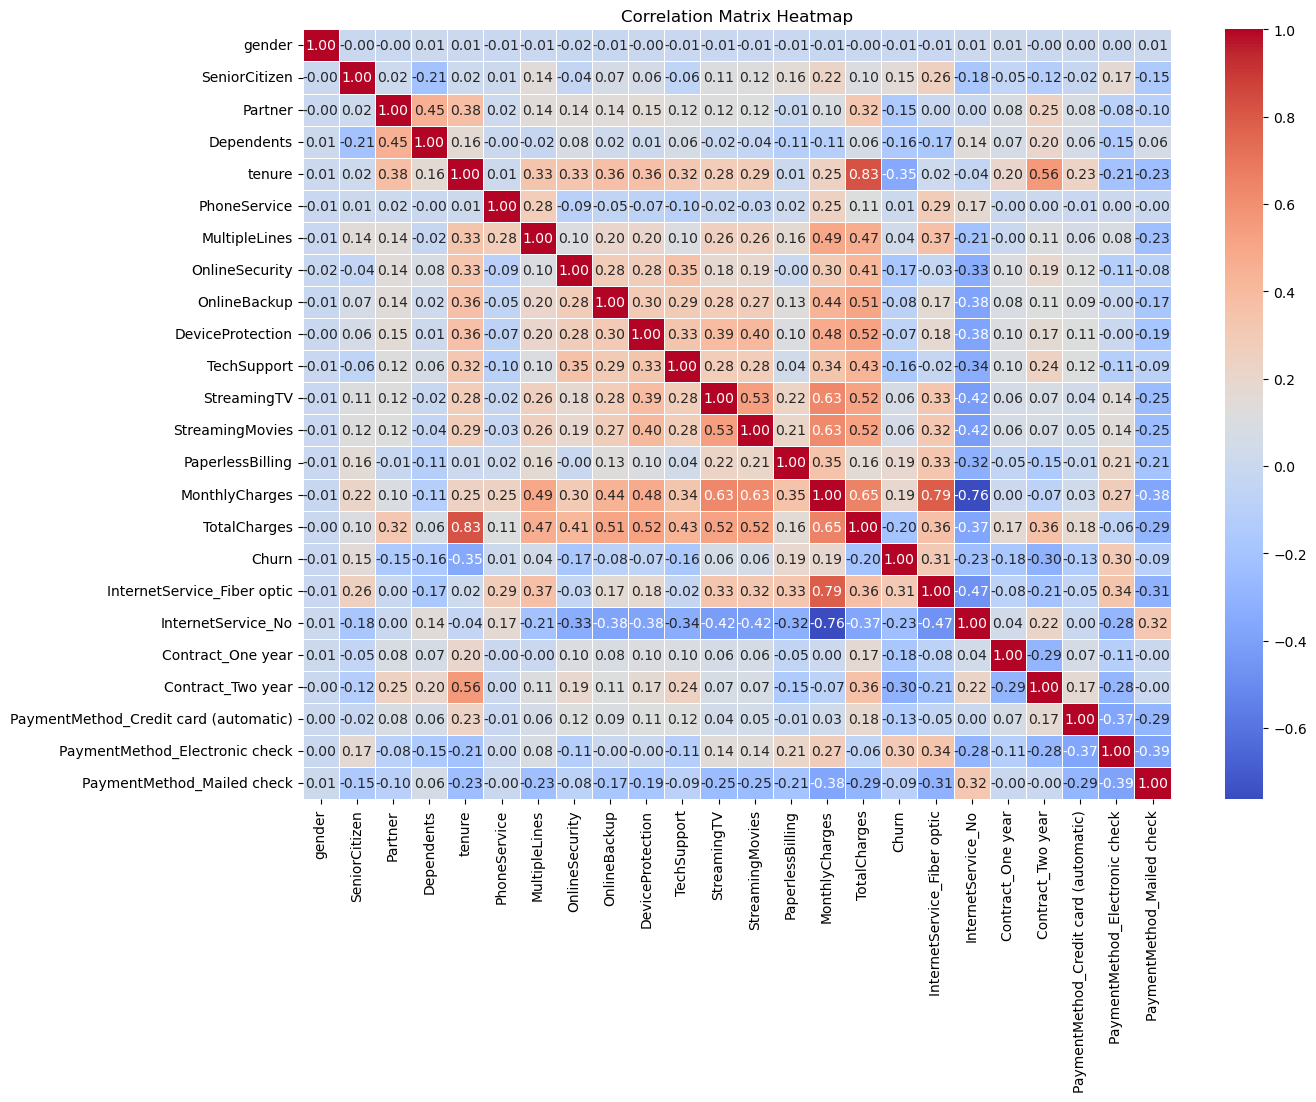

In [179]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
plt.show()

### Train - Test Split

In [180]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [181]:
feature_columns = X.columns

In [182]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [183]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [184]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [185]:
y_pred = model.predict(X_test)

### Evaluating the model

In [186]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.794889992902768


In [187]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



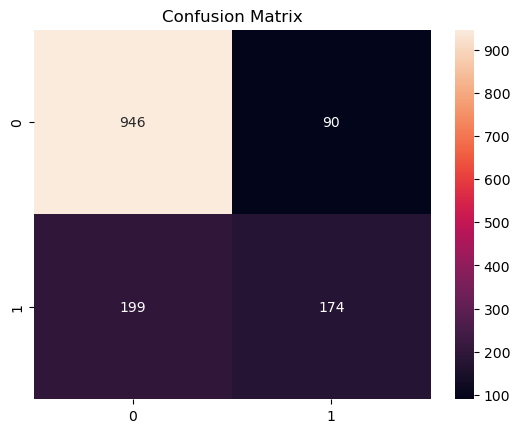

In [188]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

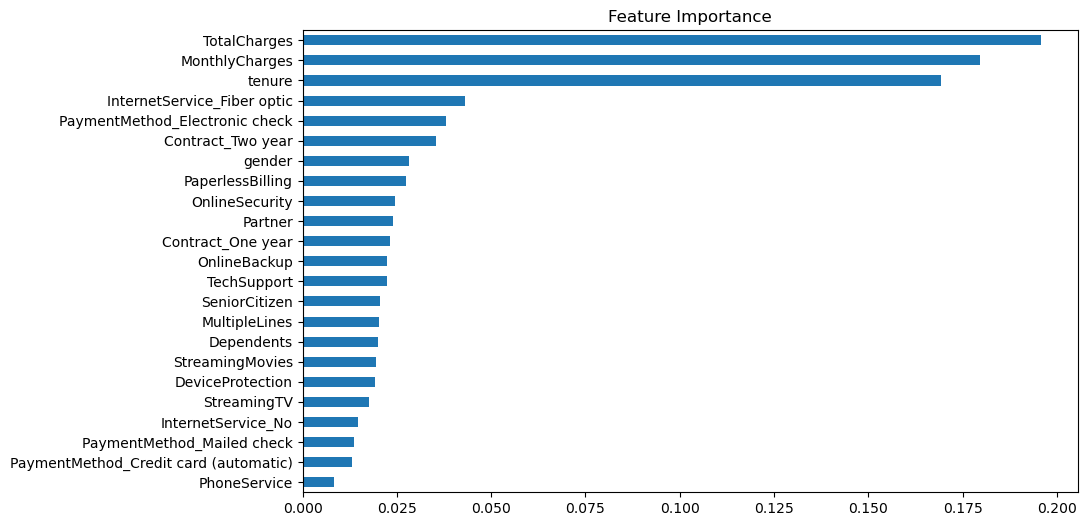

In [189]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance")
plt.show()

### Saving the Model

In [190]:
import pickle

pickle.dump(model, open("churn_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(feature_columns, open("feature_columns.pkl", "wb"))